# UHPC Compressive Strength — Exploratory Data Analysis

**Author:** K Flowers  
**Date:** January 2026

This project develops machine learning models to predict compressive strength of Ultra-High Performance Concrete (UHPC) from 810 mix design combinations. This exploratory analysis validates data quality, identifies the strongest predictors of strength, and guides model selection. Understanding these relationships supports the design of stronger UHPC formulations (the analysis uses the 150 MPa hurricane-resistant threshold as a benchmark).


**Pipeline Position:** Notebook 1 of 2 — Exploratory Analysis
- 01_exploratory_analysis.ipynb ← this notebook
- 02_model_development.ipynb

**Objective:** Validate data quality, analyze feature-target relationships, and assess multicollinearity to inform model selection for predicting UHPC compressive strength.

**Research Questions:**
This analysis addresses the following questions to inform model development:
1. **Data Quality:** Is the dataset suitable for modeling without significant cleaning or imputation?
2. **Target Distribution:** Does compressive strength require transformation for linear modeling?
3. **Feature Relationships:** Which mix design components show the strongest relationship with compressive strength?
4. **Multicollinearity:** Is there multicollinearity among features that would affect linear model stability?
5. **Model Selection:** Which modeling approaches are best suited given the observed data characteristics?

**Technical Approach:**
- Validate data quality (missing values, duplicates, invalid ranges)
- Analyze target and feature distributions
- Examine feature-target relationships and statistical significance
- Assess multicollinearity for model selection

**Inputs:**
- `data/uhpc_dataset.csv` — 810 UHPC mix designs with 13 features

**Outputs:**
- `data/uhpc_dataset_cleaned.csv` — Cleaned dataset (792 records)
- `images/` — Visualizations for analysis and reporting
- Modeling recommendations for notebook 02

---
## 1. Configure Environment

### 1.1 Import Libraries

In [1]:
# Standard library
from pathlib import Path
import warnings

# Core data libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("Libraries imported successfully")


Libraries imported successfully


In [2]:
# import buckaroo

### 1.2 Set Display and Plot Options

In [2]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Visualization settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Warnings
warnings.filterwarnings('ignore')

print("Display settings configured")

Display settings configured


### 1.3 Set Paths and Constants

In [3]:
# Project paths
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
IMAGE_DIR = PROJECT_ROOT / "images"

# Create directories if needed
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# Input/output files
INPUT_FILE = DATA_DIR / "uhpc_dataset.csv"

# Constants
RANDOM_STATE = 42

print("Paths and constants set")

Paths and constants set


### 1.4 Define Helper Functions

In [4]:
# No helper functions needed
print("Helper functions: None required")

Helper functions: None required


---
## 2. Load Data

### 2.1 Load Dataset

In [5]:
#Load the UHPC dataset from CSV file
df = pd.read_csv(INPUT_FILE)

print(f"Dataset loaded: {INPUT_FILE.name}")
print(f"  Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")

Dataset loaded: uhpc_dataset.csv
  Shape: 810 rows, 14 columns


### 2.2 Rename Columns and Review Data

In [6]:
# Rename columns from abbreviations to descriptive names
column_mapping = {
    'C': 'cement',
    'W': 'water',
    'FA': 'fly_ash',
    'SF': 'silica_fume',
    'NS': 'nano_silica',
    'QP': 'quartz_powder',
    'LP': 'limestone_powder',
    'A': 'aggregate',
    'S': 'slag',
    'SP': 'superplasticizer',
    'Fi': 'fiber',
    'T': 'temperature',
    'Age': 'age',
    'CS': 'compressive_strength'
}

df = df.rename(columns=column_mapping)

print("Columns renamed:")
print(df.columns.tolist())

Columns renamed:
['cement', 'slag', 'silica_fume', 'limestone_powder', 'quartz_powder', 'fly_ash', 'nano_silica', 'aggregate', 'water', 'fiber', 'superplasticizer', 'temperature', 'age', 'compressive_strength']


In [7]:
#  Define target variable, features, and analysis constants
TARGET = 'compressive_strength'

FEATURES = [
    'cement', 'slag', 'silica_fume', 'limestone_powder', 'quartz_powder',
    'fly_ash', 'nano_silica', 'aggregate', 'water', 'fiber',
    'superplasticizer', 'temperature', 'age'
]

HURRICANE_THRESHOLD = 150  # MPa minimum for hurricane-resistant UHPC (FHWA-HRT-18-036)

print(f"Target variable: {TARGET}")
print(f"Features: {len(FEATURES)} variables")
print(f"Hurricane threshold: {HURRICANE_THRESHOLD} MPa")

Target variable: compressive_strength
Features: 13 variables
Hurricane threshold: 150 MPa


In [8]:
# Display dataset shape, data types, and first rows
print("Data Types:")
print(df.dtypes)
df.head()

Data Types:
cement                  float64
slag                    float64
silica_fume             float64
limestone_powder        float64
quartz_powder           float64
fly_ash                 float64
nano_silica             float64
aggregate               float64
water                   float64
fiber                   float64
superplasticizer        float64
temperature               int64
age                       int64
compressive_strength    float64
dtype: object


,cement,slag,silica_fume,limestone_powder,quartz_powder,fly_ash,nano_silica,aggregate,water,fiber,superplasticizer,temperature,age,compressive_strength
0,450.0000,0.0000,50.0000,0.0000,0.0000,0.0000,0.0000,1992.0000,90.0000,0.0000,18.0000,20,28,131.0000
1,630.0000,0.0000,70.0000,0.0000,0.0000,0.0000,0.0000,1788.0000,126.0000,0.0000,18.0000,20,28,135.0000
2,810.0000,0.0000,90.0000,0.0000,0.0000,0.0000,0.0000,1539.0000,162.0000,0.0000,18.0000,20,28,137.0000
3,810.0000,0.0000,90.0000,0.0000,0.0000,0.0000,0.0000,1539.0000,162.0000,0.0000,18.0000,20,28,137.0000
4,630.0000,180.0000,90.0000,0.0000,0.0000,0.0000,0.0000,1539.0000,126.0000,0.0000,18.0000,20,28,150.0000


**Units of Measurement**

**kg/m³:** cement, slag, silica_fume, limestone_powder, quartz_powder, fly_ash, nano_silica, aggregate, water, fiber, superplasticizer   

**°C:** temperature   

**days:** age

**MPa:** compressive_strength (TARGET)

*See Appendix A for detailed validation ranges and literature sources.*

---
## 3. Validate Data Quality

**Methodology:** Data will be validated using a flag-and-filter approach. Flag variables will identify negative values, out-of-range values (see Appendix A), and duplicate records. Flagged rows are excluded from the final dataset, while the original dataset is preserved to maintain transparency and reproducibility.

### 3.1 Check Missing Values

In [10]:
# Check for missing values in each column
missing = df.isnull().sum()
max_len = max(len(col) for col in df.columns)

print("Missing Values Check:")
for col in df.columns:
    print(f"  {col:<{max_len}}: {missing[col]}")

print(f"\n  Total missing values:  {missing.sum()}")
print(f"  Columns with missing:  {(missing > 0).sum()}")

Missing Values Check:
  cement              : 0
  slag                : 0
  silica_fume         : 0
  limestone_powder    : 0
  quartz_powder       : 0
  fly_ash             : 0
  nano_silica         : 0
  aggregate           : 0
  water               : 0
  fiber               : 0
  superplasticizer    : 0
  temperature         : 0
  age                 : 0
  compressive_strength: 0

  Total missing values:  0
  Columns with missing:  0


### 3.2 Check Invalid Values

Flag rows with negative values or values outside expected ranges (see Appendix A for expected ranges).

In [11]:
# Set has_negative flag if rows have negative values
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df['has_negatives'] = (df[numeric_cols] < 0).any(axis=1)

# count rows with and without negative values
total_rows = len(df)
rows_with_negatives = df['has_negatives'].sum()
rows_without_negatives = total_rows - rows_with_negatives

print("Negative Value Check:")
print(f"  Total rows:                      {total_rows}")
print(f"  Rows with negatives (flagged):   {rows_with_negatives}")
print(f"  Rows without negatives:          {rows_without_negatives}")


Negative Value Check:
  Total rows:                      810
  Rows with negatives (flagged):   0
  Rows without negatives:          810


In [12]:
# Define validation ranges for each variable, use min, max tuples
VALIDATION_RANGES = {
    'cement':              (200, 1500),
    'slag':                (0, 600),
    'silica_fume':         (0, 500),
    'limestone_powder':    (0, 1200),
    'quartz_powder':       (0, 500),
    'fly_ash':             (0, 400),
    'nano_silica':         (0, 100),
    'aggregate':           (0, 2500),
    'water':               (50, 350),
    'fiber':               (0, 300),
    'superplasticizer':    (0, 100),
    'temperature':         (0, 250),
    'age':                 (1, 1000),
    'compressive_strength': (0, 350)
}

print("Validation Ranges:")
print(f"  {len(VALIDATION_RANGES)} ranges defined")

Validation Ranges:
  14 ranges defined


In [15]:
# Validate values against ranges (vectorized - same pattern as negatives check)
cols = [c for c in VALIDATION_RANGES.keys() if c in df.columns]
mins = pd.Series({c: VALIDATION_RANGES[c][0] for c in cols})
maxs = pd.Series({c: VALIDATION_RANGES[c][1] for c in cols})

df['has_out_of_range'] = ((df[cols] < mins) | (df[cols] > maxs)).any(axis=1)

total_rows = len(df)
rows_out_of_range = df['has_out_of_range'].sum()
rows_in_range = total_rows - rows_out_of_range

print("Range Validation Check:")
print(f"  Total rows:                     {total_rows}")
print(f"  Rows out of range (flagged):    {rows_out_of_range}")
print(f"  Rows within valid range:        {rows_in_range}")

Range Validation Check:
  Total rows:                     810
  Rows out of range (flagged):    0
  Rows within valid range:        810


### 3.3 Check Duplicates

In [17]:
# Check for duplicate rows and flag 
original_cols = [col for col in df.columns if col not in ['has_negatives', 'has_out_of_range', 'has_duplicate']]
df['has_duplicate'] = df.duplicated(subset=original_cols, keep='first')
duplicate_count = df['has_duplicate'].sum()

print("Duplicate Row Check:")
print(f"  Duplicate rows (flagged): {duplicate_count} ({duplicate_count/len(df)*100:.2f}%)")

Duplicate Row Check:
  Duplicate rows (flagged): 18 (2.22%)


**Note:** Duplicate rows (2.2%) will be removed. The dataset documentation does not indicate whether duplicates are intentional and represent repeated experiments or if they may possibly be data entry errors. The decision is to remove them to avoid artificially inflating model performance and skewing statistical measures.

### 3.4 Summary Statistics

In [13]:
# Display summary statistics for all numeric columns including non-zero counts
print("Summary Statistics:")

# Get standard describe statistics
stats_df = df.describe().T

# Add a column to count the number of non-zero records
stats_df['non_zero_records'] = (df > 0).sum()

# Rename count to total_records for clarity
stats_df = stats_df.rename(columns={'count': 'total_records'})

# Reorder columns to inlcude the count of non_zero_records after total_records
cols = ['total_records', 'non_zero_records', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
stats_df = stats_df[cols]

stats_df

Summary Statistics:


,total_records,non_zero_records,mean,std,min,25%,50%,75%,max
cement,810.0000,810,737.9146,173.4572,270.0000,620.2000,770.5000,850.0000,1251.2000
slag,810.0000,98,25.1946,74.3655,0.0000,0.0000,0.0000,0.0000,375.0000
silica_fume,810.0000,639,136.9872,104.1446,0.0000,43.7000,144.0000,219.0000,433.7000
limestone_powder,810.0000,114,41.9295,133.1315,0.0000,0.0000,0.0000,0.0000,1058.2000
quartz_powder,810.0000,132,33.2710,79.6739,0.0000,0.0000,0.0000,0.0000,397.0000
fly_ash,810.0000,117,26.2649,67.4617,0.0000,0.0000,0.0000,0.0000,356.0000
nano_silica,810.0000,211,3.6386,7.7760,0.0000,0.0000,0.0000,4.0000,47.5000
aggregate,810.0000,810,1150.1100,312.1520,407.8000,873.0000,1116.0000,1301.4000,1992.0000
water,810.0000,810,179.8911,25.5682,90.0000,163.0000,177.0000,192.5000,272.6000
fiber,810.0000,329,56.0444,75.2306,0.0000,0.0000,0.0000,156.0000,234.0000


**Modeling Implication:** Feature quantities vary widely (0–2000 kg/m³); scaling may be required during modeling.

### 3.5 Filter and Save Dataset

Filter rows with negative, out-of-range, or duplicate data and save cleaned dataset for modeling.

In [18]:
# Filter out rows with neg, out-of-range, or duplicate data 
rows_before = len(df)

# Remove rows with negatives, out-of-range values, or duplicates
df = df[~(df['has_negatives'] | df['has_out_of_range'] | df['has_duplicate'])].copy()

# Drop helper columns
df = df.drop(columns=['has_negatives', 'has_out_of_range', 'has_duplicate'])

rows_after = len(df)
rows_removed = rows_before - rows_after

print("Data Filtering Summary:")
print(f"  Rows before: {rows_before}")
print(f"  Rows removed: {rows_removed}")
print(f"  Rows after: {rows_after}")
print(f"  Retention rate: {rows_after/rows_before*100:.1f}%")

# Save cleaned dataset for modeling
OUTPUT_FILE = DATA_DIR / "uhpc_dataset_cleaned.csv"
df.to_csv(OUTPUT_FILE, index=False)
print(f"\nCleaned dataset saved: {OUTPUT_FILE.name}")

Data Filtering Summary:
  Rows before: 810
  Rows removed: 18
  Rows after: 792
  Retention rate: 97.8%

Cleaned dataset saved: uhpc_dataset_cleaned.csv


**Note:** The cleaned dataset (792 records) has been saved for modeling. All subsequent analysis uses this filtered dataset.

---
## 4. Analyze Target Variable - Compressive Strength

**Methodology:** Distribution of the target variable will be assessed using both visual diagnostics (histograms and Q–Q plots) and formal statistical testing (D’Agostino–Pearson normality test). Skewness and kurtosis will be calculated to characterize distributional shape and to determine whether transformation is warranted prior to linear modeling.

### 4.1 Distribution (Histogram + KDE)

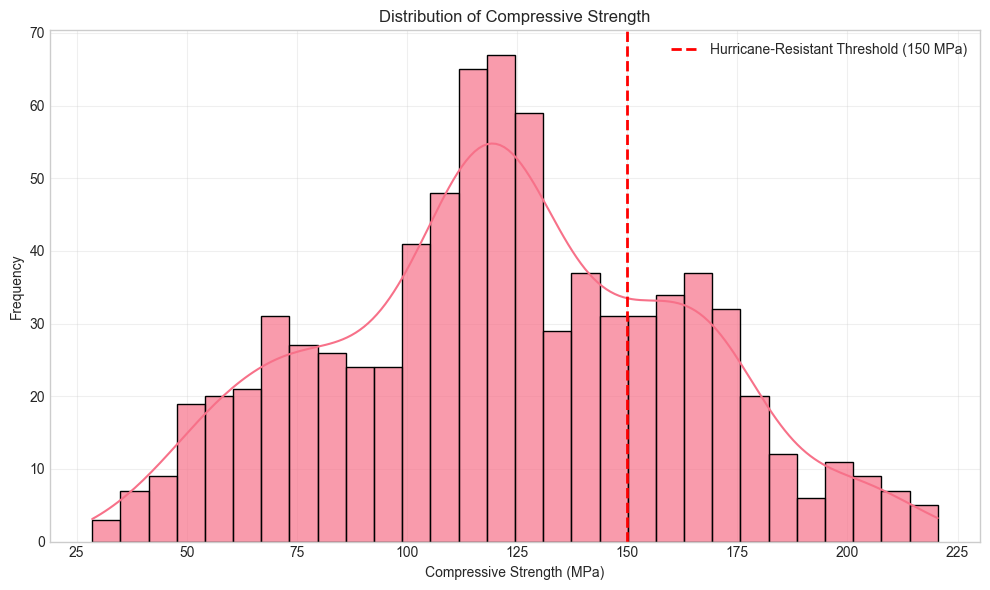

Figure saved: target_distribution.png


In [19]:
# Plot histogram with kernel density estimate for target variable
plt.figure(figsize=(10, 6))
sns.histplot(df[TARGET], kde=True, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=HURRICANE_THRESHOLD, color='red', linestyle='--', linewidth=2, 
            label=f'Hurricane-Resistant Threshold ({HURRICANE_THRESHOLD} MPa)')
plt.title(f'Distribution of Compressive Strength', fontsize=12)
plt.xlabel('Compressive Strength (MPa)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: target_distribution.png")

In [20]:
# Display descriptive statistics for target variable
print(f"Target Variable: {TARGET}\n")
print(df[TARGET].describe().round(2))
print(f"\nIQR: {df[TARGET].quantile(0.75) - df[TARGET].quantile(0.25):.2f} MPa")

Target Variable: compressive_strength

count   792.0000
mean    122.0900
std      40.0100
min      28.5100
25%      94.6000
50%     120.9000
75%     151.0000
max     220.5000
Name: compressive_strength, dtype: float64

IQR: 56.40 MPa


**Interpretation:** The histogram shows an approximately symmetric, unimodal distribution centered around 120 MPa. No obvious skewness or heavy tails are visible.

### 4.2 Normality Testing

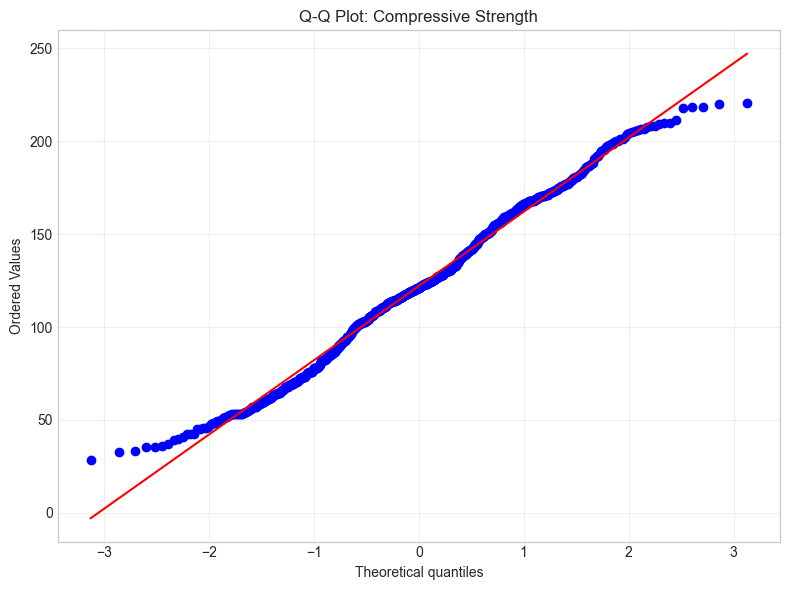

Figure saved: qq_plot_target.png


In [21]:
# Q-Q Plot to visually assess normality
target_sample = df[TARGET].sample(5000, random_state=RANDOM_STATE) if len(df) > 5000 else df[TARGET]

fig, ax = plt.subplots(figsize=(8, 6))
stats.probplot(target_sample, dist="norm", plot=ax)
ax.set_title('Q-Q Plot: Compressive Strength')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'qq_plot_target.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: qq_plot_target.png")

In [22]:
# D'Agostino-Pearson test for normality (appropriate for n > 20)
stat, p_value = stats.normaltest(target_sample)

print("D'Agostino-Pearson Test:")
print(f"  Statistic: {stat:.4f}")
print(f"  p-value:   {p_value:.4f}")
print(f"  Result:    {'Normal' if p_value >= 0.05 else 'Not normal'} (α = 0.05)")

D'Agostino-Pearson Test:
  Statistic: 15.2868
  p-value:   0.0005
  Result:    Not normal (α = 0.05)


In [24]:
skew = df[TARGET].skew()
kurt = df[TARGET].kurtosis()

# Evaluate kurtosis - |k| > 1 indicates non-normal tails
print("Shape Statistics:")
print(f"    Skewness: {skew:.3f} —", 
      "Approximately symmetric" if abs(skew) < 0.5 else
      "Moderately skewed" if abs(skew) < 1 else
      "Highly skewed (consider transformation)")

# Evaluate kurtosis - |k| > 1 indicates non-normal tails

print(f"    Kurtosis: {kurt:.3f} —", 
      "Near normal tails" if abs(kurt) < 1 else
      "Heavy tails" if kurt > 1 else
      "Light tails")


Shape Statistics:
    Skewness: 0.034 — Approximately symmetric
    Kurtosis: -0.506 — Near normal tails


**Interpretation:** The Q-Q plot shows points closely following the diagonal reference line. While the D'Agostino-Pearson test formally rejects normality (p < 0.001), this is expected with large samples (n=792). The shape statistics (skewness: 0.03, kurtosis: -0.51) indicate the distribution is approximately symmetric with near-normal tails

**Modeling Implication:** Based on these results, no initial transformation of the target variable appears necessary. RMSE should be appropriate for model evaluation. Residual normality will be assessed during modeling to confirm this assumption.

In [26]:
# Calculate percentage of samples meeting hurricane-resistant threshold
above_threshold = (df[TARGET] >= HURRICANE_THRESHOLD).sum()
below_threshold = len(df) - above_threshold

print(f"Hurricane-Resistant Threshold Analysis ({HURRICANE_THRESHOLD} MPa):")
print(f"  Samples >= {HURRICANE_THRESHOLD} MPa: {above_threshold} ({above_threshold/len(df)*100:.1f}%)")
print(f"  Samples <  {HURRICANE_THRESHOLD} MPa: {below_threshold} ({below_threshold/len(df)*100:.1f}%)")
print(f"\n  Mean strength above threshold: {df[df[TARGET] >= HURRICANE_THRESHOLD][TARGET].mean():.2f} MPa")
print(f"  Mean strength below threshold: {df[df[TARGET] < HURRICANE_THRESHOLD][TARGET].mean():.2f} MPa")

Hurricane-Resistant Threshold Analysis (150 MPa):
  Samples >= 150 MPa: 210 (26.5%)
  Samples <  150 MPa: 582 (73.5%)

  Mean strength above threshold: 172.83 MPa
  Mean strength below threshold: 103.78 MPa


**Modeling Implication:**  For regression modeling, the imbalance does not require resampling (unlike classification). However, stratification of train/test splits may be used to ensure both sets have representative samples above and below the hurricane-resistant threshold.


---
## 5. Analyze Feature Variables

**Methodology:** Feature variables will first be examined using visual diagnostics, including histograms and box plots, along with skewness assessment to evaluate distributional characteristics and identify potential anomalies. Feature–target relationships will then be assessed using Pearson correlation coefficients with significance testing. Effect sizes will be interpreted using engineering conventions (|r| < 0.3 = weak, 0.3–0.7 = moderate, > 0.7 = strong). Scatter plots will be used to visually assess linearity for the strongest predictors.

### 5.1 Feature Distributions (Histograms + KDE)

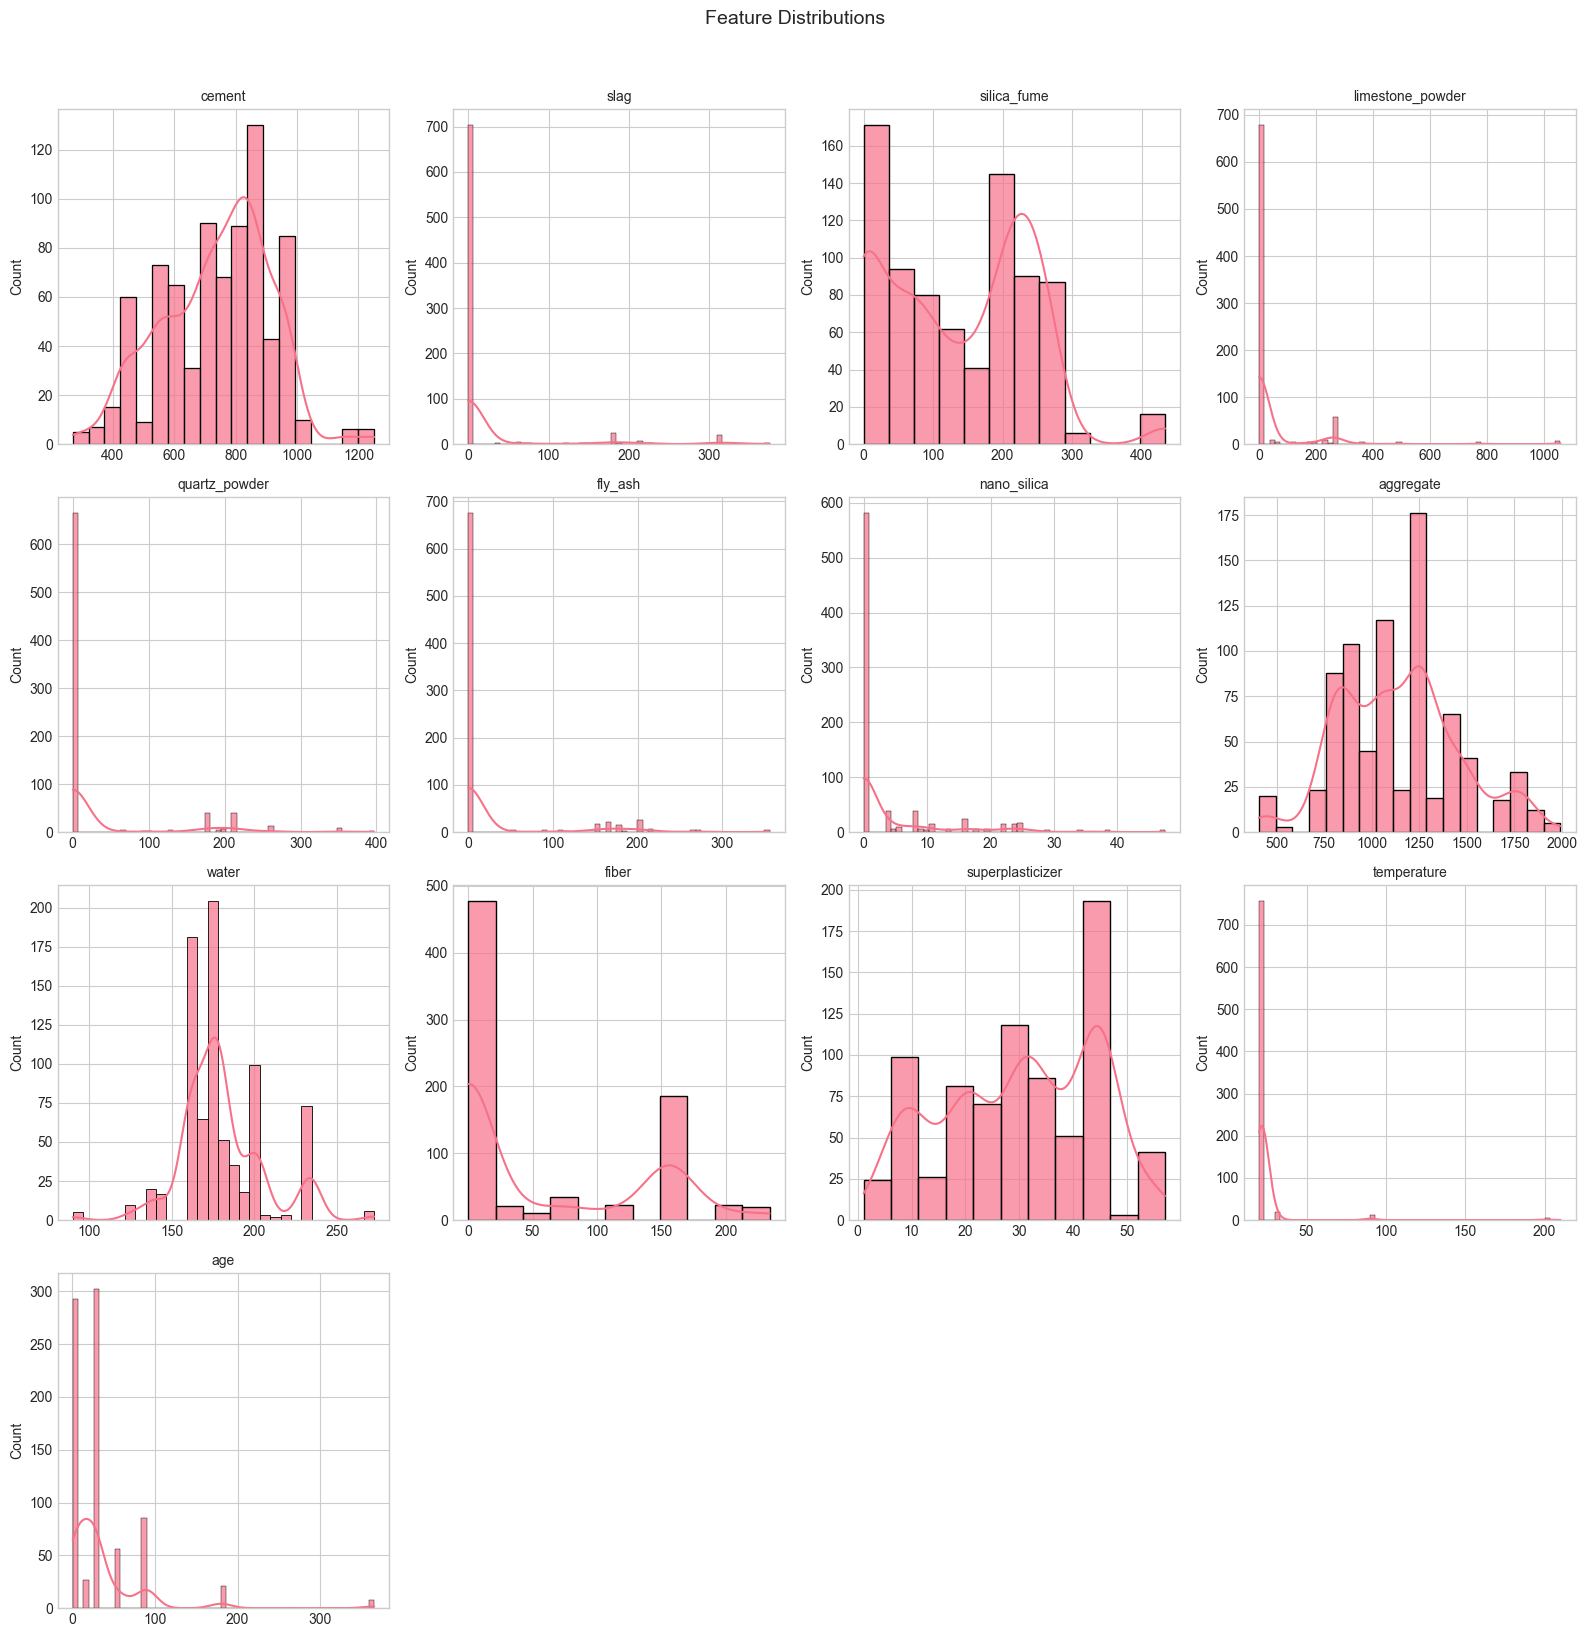

Figure saved: feature_distributions.png


In [27]:
# Create histogram grid showing distribution of all features, distributions reveal skewness, modality, and transformation needs
n_features = len(FEATURES)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.ravel()

for i, col in enumerate(FEATURES):
    sns.histplot(df[col], kde=True, ax=axes[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: feature_distributions.png")

**Interpretation:** Feature distributions show two distinct patterns:
- **Always present:** Some features (cement, water, aggregate, superplasticizer) have non-zero values in all samples
- **Zero-inflated:** Other features show many zero values, indicating they are not included in all mix designs

**Modeling Implication:** Zero-inflated features may favor tree-based models over linear models. Standard log transforms are not applicable on zero values and log(x+1) may need to be evaluated if transformations are needed.

### 5.2 Outlier Detection (Boxplots)

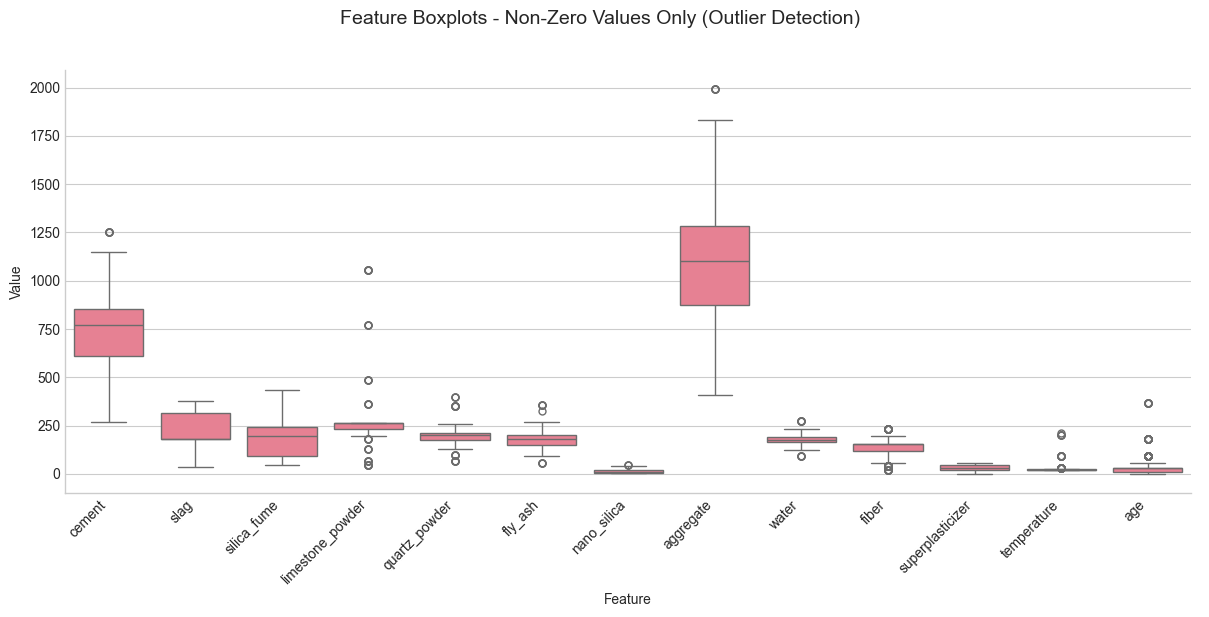


Figure saved: feature_boxplots.png


In [28]:
# Create boxplots for non-zero values using melt + seaborn filter to > 10 non-zero records
features_with_data = [col for col in FEATURES if (df[col] > 0).sum() > 10]

# Melt dataframe and filter to non-zero values
df_melted = df[features_with_data].melt(var_name='feature', value_name='value')
df_melted = df_melted[df_melted['value'] > 0]

# Create faceted boxplots (vertical orientation)
g = sns.catplot(
    data=df_melted, 
    x='feature', 
    y='value',
    kind='box',
    height=6,
    aspect=2
)
g.set_xticklabels(rotation=45, ha='right')
g.set_axis_labels('Feature', 'Value')
g.fig.suptitle('Feature Boxplots - Non-Zero Values Only (Outlier Detection)', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved: feature_boxplots.png")

**Interpretation:** Boxplots (non-zero values only) corroborate the scale differences seen in histograms and reveal outliers in `temperature` and `age`. Outliers appear to represent valid experimental conditions rather than data errors—removal does not appear warranted. 

**Modeling Implication:** Scale differences reinforce the need for feature scaling during modeling.

### 5.3 Skewness Assessment

In [29]:
# Calculate absolute skewness and kurtosis for all features
skew_df = pd.DataFrame({
    '|Skewness|': df[FEATURES].skew().abs(),
    'Kurtosis': df[FEATURES].kurtosis()
}).sort_values('|Skewness|', ascending=False)

print("Feature Shape Statistics (sorted by |skewness|):")
print(skew_df.round(2))
print(f"\nFeatures with |skew| > 1: {(skew_df['|Skewness|'] > 1).sum()}")

Feature Shape Statistics (sorted by |skewness|):
                  |Skewness|  Kurtosis
temperature           9.0400   89.6500
limestone_powder      4.7000   27.6500
age                   3.8900   20.5400
slag                  3.1800    9.1900
nano_silica           2.4900    6.4800
fly_ash               2.4500    5.1200
quartz_powder         2.3100    4.4000
fiber                 0.8100   -0.9900
water                 0.6000    1.7100
aggregate             0.2700   -0.1200
silica_fume           0.2500   -0.6100
cement                0.2300   -0.1600
superplasticizer      0.2000   -1.0700

Features with |skew| > 1: 7


**Interpretation:** Seven features show high skewness (|skew| > 1), primarily due to zero-inflation.

**Modeling Implication:** These are flagged as potential transformation candidates; however, the need for transformation depends on model type. Tree-based models handle skewness naturally and will be evaluated during model development.

### 5.4 Feature-Target Correlations

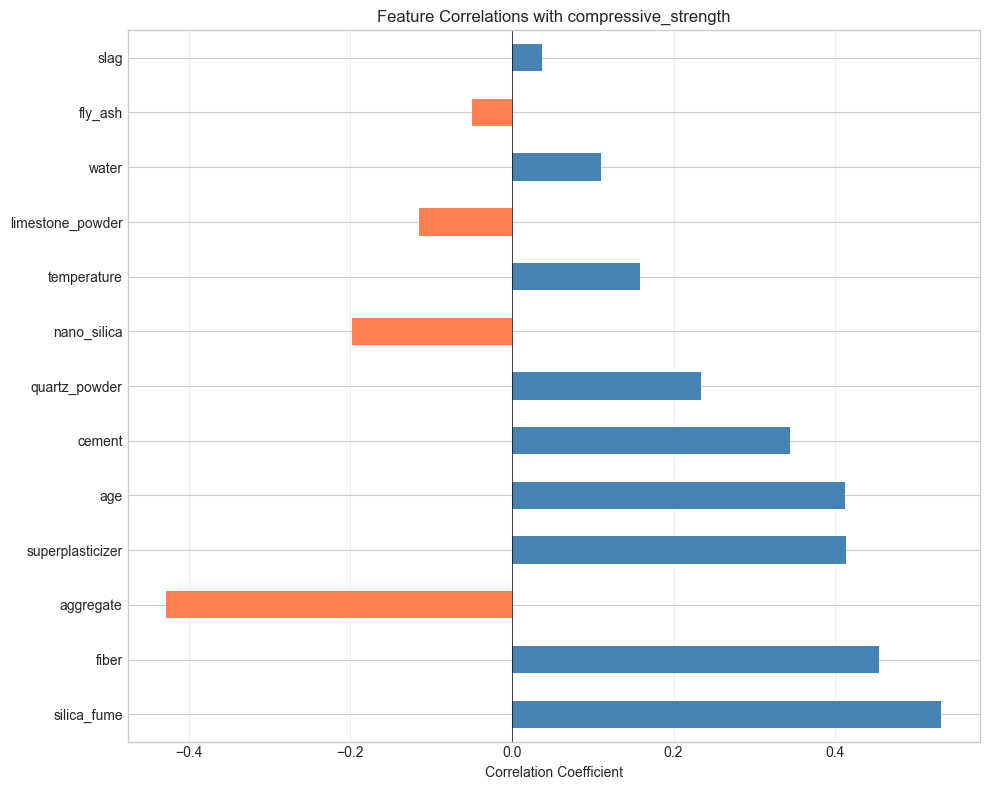


Figure saved: correlation_bar_chart.png


In [31]:
# Calculate Pearson correlations between all features and target
correlations = df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

# Create horizontal bar chart of correlations sorted by absolute value
plt.figure(figsize=(10, 8))
colors = np.where(correlations >= 0, 'steelblue', 'coral')
correlations.plot(kind='barh', color=colors)
plt.xlabel('Correlation Coefficient')
plt.title(f'Feature Correlations with {TARGET}', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'correlation_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved: correlation_bar_chart.png")

In [ ]:
# Calculate Pearson correlations between all features and target
correlations = df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

# Create horizontal bar chart of correlations sorted by absolute value
plt.figure(figsize=(10, 8))
colors = np.where(correlations >= 0, 'steelblue', 'coral')
correlations.plot(kind='barh', color=colors)
plt.xlabel('Correlation Coefficient')
plt.title(f'Feature Correlations with {TARGET}', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'correlation_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: correlation_bar_chart.png")

**Interpretation:** Six features show moderate correlation with compressive strength (|r| 0.3–0.7): silica_fume, fiber, aggregate, superplasticizer, age, and cement. These appear to be the strongest linear predictors in this dataset. The remaining seven features show weak correlation (|r| < 0.3).

### 5.5 Statistical Significance Testing

In [33]:
# Calculate p-values for correlations to assess statistical significance
alpha = 0.05

sig_df = pd.DataFrame({
    'Feature': FEATURES,
    'Correlation': [df[col].corr(df[TARGET]) for col in FEATURES],
    'p_value': [stats.pearsonr(df[col], df[TARGET])[1] for col in FEATURES]
})
sig_df['Significant'] = sig_df['p_value'] < alpha
sig_df = sig_df.sort_values('p_value')

print(f"Statistical Significance Testing (α = {alpha}):")
print(sig_df.round(4).to_string(index=False))

print(f"\nSignificant correlations: {sig_df['Significant'].sum()} / {len(FEATURES)}")

Statistical Significance Testing (α = 0.05):
         Feature  Correlation  p_value  Significant
     silica_fume       0.5312   0.0000         True
           fiber       0.4546   0.0000         True
       aggregate      -0.4275   0.0000         True
superplasticizer       0.4131   0.0000         True
             age       0.4119   0.0000         True
          cement       0.3439   0.0000         True
   quartz_powder       0.2344   0.0000         True
     nano_silica      -0.1975   0.0000         True
     temperature       0.1583   0.0000         True
limestone_powder      -0.1145   0.0012         True
           water       0.1099   0.0019         True
         fly_ash      -0.0490   0.1685        False
            slag       0.0374   0.2930        False

Significant correlations: 11 / 13


**Interpretation:** 11 of 13 features show statistically significant correlations with compressive strength. 

 **Modeling Implication:** These findings should be evaluated during modeling using LASSO regularization and tree-based feature importance.

### 5.6 Scatter Plots (Top 5 Correlated Features)

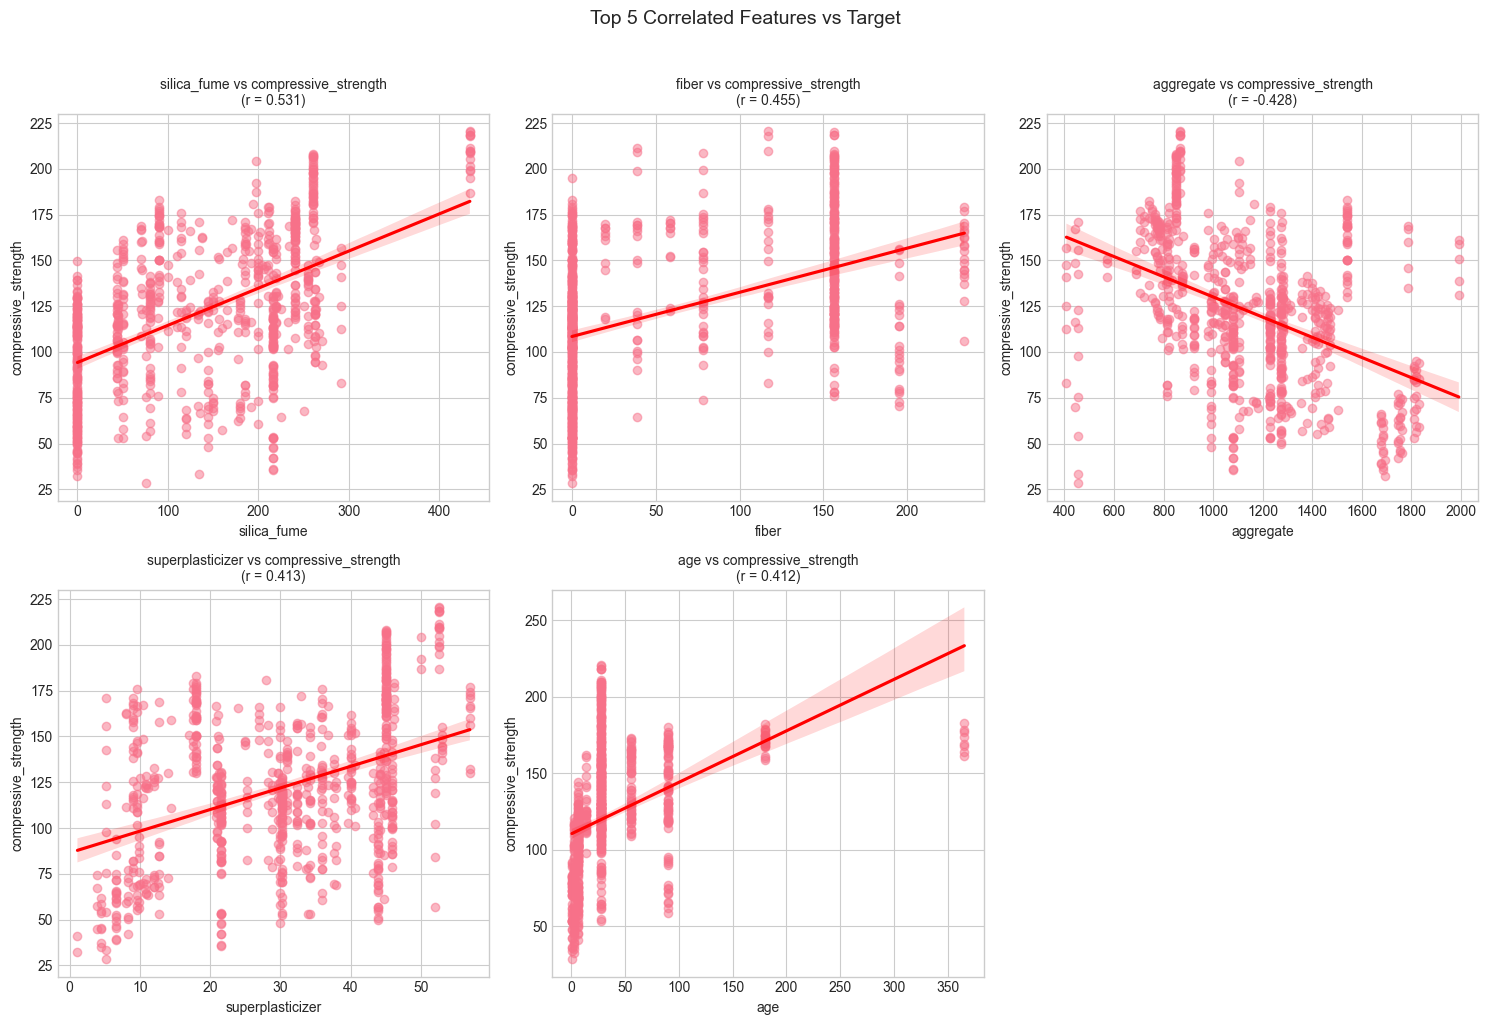

Figure saved: top5_scatter_plots.png


In [34]:
# Create scatter plots with regression lines for top 5 correlated features to reveal linearity, heteroscedasticity, and influential points
top_5 = correlations.head(5).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(top_5):
    sns.regplot(x=df[col], y=df[TARGET], ax=axes[i], scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
    axes[i].set_title(f'{col} vs {TARGET}\n(r = {correlations[col]:.3f})', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(TARGET)

axes[5].set_visible(False)

plt.suptitle('Top 5 Correlated Features vs Target', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'top5_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: top5_scatter_plots.png")

**Interpretation:** Scatter plots confirm approximately linear relationships for the top 5 correlated features. No obvious heteroscedasticity (variance appears consistent across ranges) or influential outliers were observed. Fiber shows a zero-spike pattern consistent with zero-inflation noted earlier.

---
## 6. Assess Multicollinearity 

**Methodology:** Multicollinearity among feature variables will be assessed using a combination of correlation-based and regression-based diagnostics. A correlation heatmap will be used to visualize pairwise relationships across all features and to identify potential multicollinearity patterns. Highly correlated feature pairs will be examined to evaluate redundancy and potential impacts on model stability. Variance Inflation Factors (VIF) will then be calculated to quantify the degree of multicollinearity among predictors within the regression framework and to inform feature retention or modification decisions.

### 6.1 Correlation Heatmap (All Features)

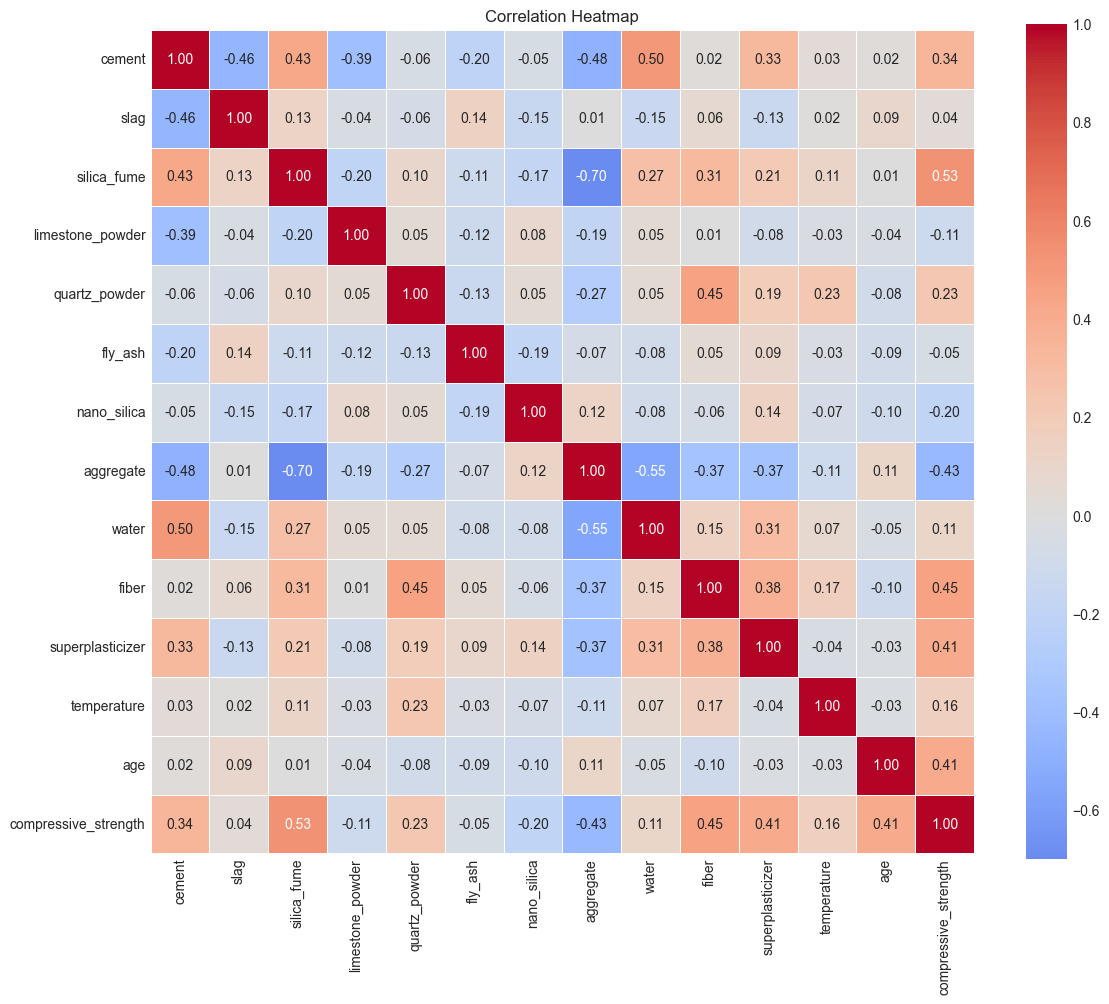

Figure saved: correlation_heatmap.png


In [38]:
# Create correlation heatmap for all features to reveal multicollinearity patterns that affect linear model stability
plt.figure(figsize=(12, 10))
corr_matrix = df[FEATURES + [TARGET]].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=12)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: correlation_heatmap.png")

**Interpretation:** The heatmap reveals moderate correlations among a few ingredients (cement, water, aggregate, silica_fume). The strongest feature-feature correlation (silica_fume–aggregate: r=-0.70) is moderately strong but does not exceed the multicollinearity threshold.

### 6.2 Highly Correlated Feature Pairs

Identify pairs with |r| > 0.7 

In [39]:
# Show all pairwise correlations sorted by absolute value
CORR_THRESHOLD = 0.7

feature_corr = df[FEATURES].corr()

# Extract upper triangle of correlation matrix (exclude diagonal)
corr_pairs = []
for i in range(len(FEATURES)):
    for j in range(i+1, len(FEATURES)):
        corr_pairs.append({
            'Feature_1': FEATURES[i],
            'Feature_2': FEATURES[j],
            'Correlation': feature_corr.iloc[i, j]
        })

pairs_df = pd.DataFrame(corr_pairs)
pairs_df['Abs_Corr'] = pairs_df['Correlation'].abs()
pairs_df = pairs_df.sort_values('Abs_Corr', ascending=False).drop(columns='Abs_Corr')

# Classify correlation strength
pairs_df['Strength'] = pd.cut(
    pairs_df['Correlation'].abs(),
    bins=[0, 0.3, 0.7, 1.0],
    labels=['Weak', 'Moderate', 'Strong']
)

# Show distribution summary
print("Correlation Strength Distribution:")
print(f"  Strong (|r| > 0.7):   {(pairs_df['Strength'] == 'Strong').sum()}")
print(f"  Moderate (0.3-0.7):   {(pairs_df['Strength'] == 'Moderate').sum()}")
print(f"  Weak (|r| < 0.3):     {(pairs_df['Strength'] == 'Weak').sum()}")
print(f"  Total pairs:          {len(pairs_df)}")

# Show top correlations
print(f"\nTop 10 Feature Pair Correlations (sorted by |r|):")
print(pairs_df.head(10).to_string(index=False))

# Flag high correlations
high_corr = pairs_df[pairs_df['Correlation'].abs() > CORR_THRESHOLD]
if len(high_corr) > 0:
    print(f"\n {len(high_corr)} pairs exceed threshold (|r| > {CORR_THRESHOLD})")
else:
    print(f"\n No feature pairs exceed threshold (|r| > {CORR_THRESHOLD})")

Correlation Strength Distribution:
  Strong (|r| > 0.7):   0
  Moderate (0.3-0.7):   14
  Weak (|r| < 0.3):     64
  Total pairs:          78

Top 10 Feature Pair Correlations (sorted by |r|):
    Feature_1        Feature_2  Correlation Strength
  silica_fume        aggregate      -0.6992 Moderate
    aggregate            water      -0.5540 Moderate
       cement            water       0.5012 Moderate
       cement        aggregate      -0.4751 Moderate
       cement             slag      -0.4587 Moderate
quartz_powder            fiber       0.4546 Moderate
       cement      silica_fume       0.4291 Moderate
       cement limestone_powder      -0.3911 Moderate
        fiber superplasticizer       0.3814 Moderate
    aggregate superplasticizer      -0.3693 Moderate

 No feature pairs exceed threshold (|r| > 0.7)


**Interpretation:** No feature pairs exceed the |r| > 0.7 threshold for severe multicollinearity. 

### 6.3 Variance Inflation Factor (VIF)

In [37]:
# Calculate Variance Inflation Factor for each feature using pd.cut for classification
X = df[FEATURES].dropna()

# Calculate VIF for all features
vif_values = [variance_inflation_factor(X.values, i) for i, col in enumerate(FEATURES)]

# Create dataframe and classify severity using pd.cut
vif_df = pd.DataFrame({'Feature': FEATURES, 'VIF': vif_values})
vif_df['Multicollinearity'] = pd.cut(
    vif_df['VIF'],
    bins=[0, 5, 10, float('inf')],
    labels=['OK', 'Moderate', 'Severe']
)
vif_df = vif_df.sort_values('VIF', ascending=False)

print("Variance Inflation Factors:")
print("  Interpretation (Hair et al., 2010): OK (VIF ≤ 5) | Moderate (5-10) | Severe (>10)")
print()
print(vif_df.round(2).to_string(index=False))

# Summary
print(f"\nSummary:")
print(f"  Severe (VIF > 10):  {(vif_df['Multicollinearity'] == 'Severe').sum()}")
print(f"  Moderate (5-10):    {(vif_df['Multicollinearity'] == 'Moderate').sum()}")
print(f"  OK (VIF ≤ 5):       {(vif_df['Multicollinearity'] == 'OK').sum()}")

Variance Inflation Factors:
  Interpretation (Hair et al., 2010): OK (VIF ≤ 5) | Moderate (5-10) | Severe (>10)

         Feature     VIF Multicollinearity
           water 72.7100            Severe
          cement 59.1200            Severe
       aggregate 13.3700            Severe
superplasticizer  8.6400          Moderate
     silica_fume  5.8800          Moderate
     temperature  3.4400                OK
           fiber  2.5600                OK
            slag  1.8100                OK
limestone_powder  1.7500                OK
   quartz_powder  1.6600                OK
             age  1.6300                OK
     nano_silica  1.4400                OK
         fly_ash  1.4100                OK

Summary:
  Severe (VIF > 10):  3
  Moderate (5-10):    2
  OK (VIF ≤ 5):       8


**Interpretation:** Three features (water, cement, aggregate) show severe multicollinearity with VIF > 10. These features showed moderate pairwise correlations in section 6.2, confirming they form a collinear cluster related to fundamental mix proportions.

**Modeling Implication:** Multicollinearity may cause unstable coefficients in ordinary least squares regression. This further emphasizes the need to evaluate regularized models (Ridge, LASSO). Tree-based models are unaffected by multicollinearity and can use all features directly.

---
## 7. Conclusion

This exploratory analysis examined the UHPC dataset to identify patterns that will inform model development. The findings below summarize data quality, distribution characteristics, and feature relationships, along with modeling recommendations based on these observations.


**Key Findings:**

*Data Quality:*
- Dataset is clean: no missing values, no out-of-range values, and 18 duplicate rows removed (2.2%), leaving 792 records

*Target Distribution:*
- Compressive strength is approximately normal (mean: 122 MPa, std: 40 MPa, skewness: 0.03) — no transformation required
- 26.5% of samples meet hurricane-resistant threshold (≥150 MPa)

*Feature-Target Relationships:*
- Strongest predictors: silica_fume (r=0.53), fiber (r=0.45), aggregate (r=-0.43)
- 6 features show moderate correlation (|r| 0.3-0.7); 7 features show weak correlation (|r| < 0.3)
- Approximately linear relationships observed; no feature transformations needed

*Multicollinearity:*
- 3 features with severe VIF (>10): water, cement, aggregate — regularization required for linear models
- No feature pairs exceed |r| > 0.7 threshold

**Modeling Implications:**

Given the above data characteristics, the following implications for modeling were identified:
- Target is approximately normal → no transformation needed; RMSE appropriate for evaluation
- High VIF values → regularization required for linear models
- Linear relationships observed → both linear and tree-based models are viable
- 13 features is manageable → no dimensionality reduction needed

**Candidate Models:**

Based on these findings, the following models will be evaluated in notebook 02:
- *Baseline:* Linear Regression
- *Regularized (for multicollinearity):* Ridge, LASSO, Elastic Net
- *Tree-based (handles skewness, no scaling needed):* Random Forest, Gradient Boosting

**Limitations:**
- Dataset size (n=792) may limit model complexity
- 7 features highly skewed due to zero-inflation (optional components)
- Fiber and aggregate types unspecified

**Outputs:**
- `data/uhpc_dataset_cleaned.csv` — Cleaned dataset ready for modeling
- `images/` — Visualizations saved for reporting

**Next Steps:**
Proceed to **02_model_development.ipynb** for feature engineering and model comparison.

---
## Appendix A: Data Validation Ranges

**Disclaimer:** Due diligence was done to research valid ranges to apply to the data based on UHPC literature. However, values should be further justified before applying to real-world scenarios.

**Notes:**
- `fiber` and `aggregate` have material types unspecified in the dataset (fiber could be steel, polypropylene, glass, carbon, or basalt; aggregate type varies), so only basic range validation (non-negative, reasonable maximum) is applied.
- Validation ranges are intentionally wider than typical ranges to avoid flagging valid experimental data while still catching obvious errors (e.g., wrong units, misplaced decimals).

| Variable | Typical Range | Min Valid | Max Valid | Unit |
|----------|---------------|-----------|-----------|------|
| cement | 700-1000 | 200 | 1500 | kg/m³ |
| slag | 0-400 | 0 | 600 | kg/m³ |
| silica_fume | 150-300 | 0 | 500 | kg/m³ |
| limestone_powder | 0-300 | 0 | 1200 | kg/m³ |
| quartz_powder | 0-400 | 0 | 500 | kg/m³ |
| fly_ash | 0-200 | 0 | 400 | kg/m³ |
| nano_silica | 0-50 | 0 | 100 | kg/m³ |
| aggregate | *unspecified* | 0 | 2500 | kg/m³ |
| water | 150-200 | 50 | 350 | kg/m³ |
| fiber | *unspecified* | 0 | 300 | kg/m³ |
| superplasticizer | 10-60 | 0 | 100 | kg/m³ |
| temperature | 20-90 | 0 | 250 | °C |
| age | 1-365 | 1 | 1000 | days |
| compressive_strength | 120-250 | 0 | 350 | MPa |

**Sources:**
- FHWA-HRT-13-060 (June 2013) — cement, water, compressive_strength ranges
- PMC9228538 (June 2022) — silica_fume, limestone_powder, quartz_powder, superplasticizer ranges
- PMC5455500 (August 2015) — temperature, age ranges
- Springer Pozzolanic Materials (May 2025) — slag, fly_ash ranges
- ScienceDirect Nano-silica (May 2014) — nano_silica ranges

---
## Appendix B: References

Cohen, J. (1988). *Statistical Power Analysis for the Behavioral Sciences* (2nd ed.). Lawrence Erlbaum Associates.

Hair, J. F., Black, W. C., Babin, B. J., & Anderson, R. E. (2010). *Multivariate Data Analysis* (7th ed.). Pearson.

Federal Highway Administration. (2013). *Ultra-High Performance Concrete: A State-of-the-Art Report for the Bridge Community* (FHWA-HRT-13-060).

Federal Highway Administration. (2018). *Properties and Behavior of UHPC-Class Materials* (FHWA-HRT-18-036).

Shi, C., Wu, Z., Xiao, J., Wang, D., Huang, Z., & Fang, Z. (2015). A review on ultra high performance concrete: Part I. Raw materials and mixture design. *Construction and Building Materials*, 101, 741-751.

Siddique, R. & Khan, M. I. (2011). *Supplementary Cementing Materials*. Springer.